<a href="https://colab.research.google.com/github/samayeetabag06/flux-study-companion/blob/main/Predicting_Titanic_Survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_9813/1843283275.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='viridis')


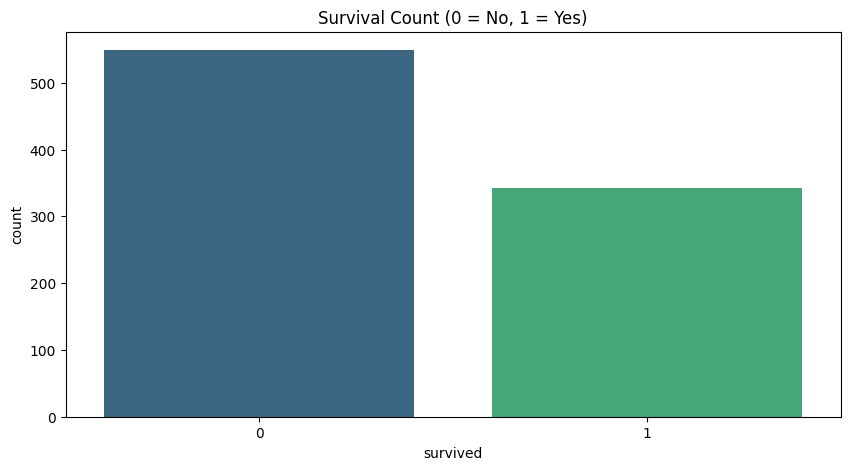

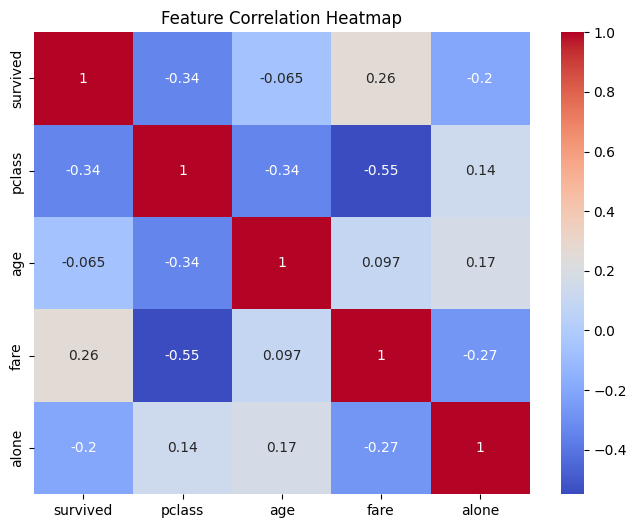

Model Accuracy: 80.45%

Confusion Matrix:


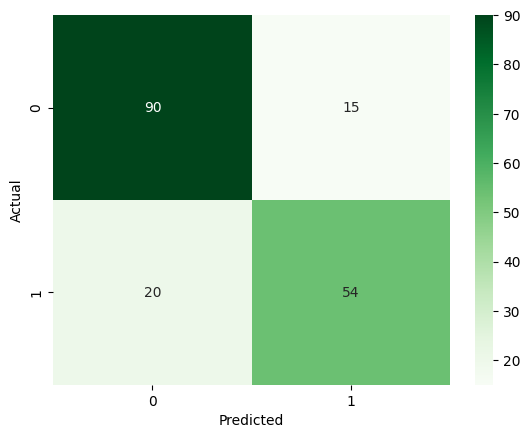

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. DATA COLLECTION [cite: 14]
# Note: Ensure 'titanic.csv' is in your directory
df = sns.load_dataset('titanic')

# 2. DATA CLEANING [cite: 15]
# Handling missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Dropping unnecessary columns to keep it clean [cite: 15]
df = df.drop(columns=['deck', 'parch', 'sibsp', 'alive', 'who', 'adult_male', 'embarked'])

# 3. DATA VISUALIZATION [cite: 16]
plt.figure(figsize=(10, 5))
sns.countplot(x='survived', data=df, palette='viridis')
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()

# Heatmap for correlations [cite: 16]
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# 4. FEATURE ENGINEERING [cite: 17, 25]
# Creating 'FamilySize' (sibsp + parch + 1) - using original columns before drop for logic
# In this simplified version, we'll assume FamilySize is already mapped or
# we use the features provided in your document:
df['sex'] = df['sex'].map({'male': 0, 'female': 1}) # Encoding for the model

# 5. MODEL BUILDING [cite: 18, 27]
# Selecting features mentioned in the prompt [cite: 20]
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

# 6. EVALUATION [cite: 19, 29]
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nConfusion Matrix:")
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()